# 이커머스 고객 세분화와 재구매 분석 워크북

이 노트북은 공개 가능한 비식별 집계에서 README의 핵심 결과를 다시 계산한다. 원본 고객 단위 분석은 `scripts/validate_source_data.py`, 쿠폰 모집단 생성은 `scripts/build_coupon_population.py`, 매칭은 `scripts/run_coupon_matching.py`가 담당한다.

분석 기준은 BigQuery Standard SQL이며, 결과는 기술통계와 관찰 차이로 제한한다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'data' / 'derived').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'derived'

segment = pd.read_csv(DATA / 'segment_revenue_share.csv')
cohort = pd.read_csv(DATA / 'cohort_retention_snapshot.csv')
activity = pd.read_csv(DATA / 'activity_ladder_summary.csv')
effects = pd.read_csv(DATA / 'matched_effects.csv')
balance = pd.read_csv(DATA / 'matched_balance.csv')

print('Loaded aggregate snapshots from', DATA.relative_to(ROOT))

Loaded aggregate snapshots from data/derived


## 1. 결과 정합성 확인

고객 수, 매출 비중, 코호트 관측 구조와 쿠폰 매칭 표본을 먼저 대조한다.

In [2]:
m1_values = cohort.loc[cohort['m1'].notna(), 'm1']
matched_rows = effects[effects['method'].eq('72쌍 매칭 차이')].set_index('outcome')
summary = pd.Series({
    'customers': int(segment['customers'].sum()),
    'observed_revenue': round(segment['revenue'].sum(), 2),
    'top_two_revenue_share_pct': round(segment.head(2)['revenue_share_pct'].sum(), 1),
    'm1_simple_mean_pct': round(m1_values.mean(), 2),
    'customers_with_2plus_transactions': int(activity.iloc[1]['reached']),
    'matched_pairs': int(matched_rows.iloc[0]['n_treat']),
    'imbalanced_covariates': int(balance['smd_after'].abs().ge(0.1).sum()),
})
assert summary['customers'] == 1468
assert summary['top_two_revenue_share_pct'] == 68.3
assert summary['m1_simple_mean_pct'] == 9.68
assert summary['matched_pairs'] == 72
assert summary['imbalanced_covariates'] == 6
summary.to_frame('value')

,value
customers,1468.00
observed_revenue,5079712.00
top_two_revenue_share_pct,68.30
m1_simple_mean_pct,9.68
customers_with_2plus_transactions,1343.00
matched_pairs,72.00
imbalanced_covariates,6.00


## 2. 세그먼트와 매출 집중

Monetary가 RFM 분류 변수이므로 매출 비중은 독립적인 모델 성능이 아니라 분류 결과의 규모를 설명한다.

,segment,customers,revenue,revenue_share_pct
0,성장형 고객,349,1983013,39.0
1,핵심 파트너 고객,122,1487363,29.3
2,장기 비활성 고객,330,841780,16.6
3,이탈 위험 고객,298,365710,7.2
4,유망 고객,317,333727,6.6
5,기타,52,68119,1.3


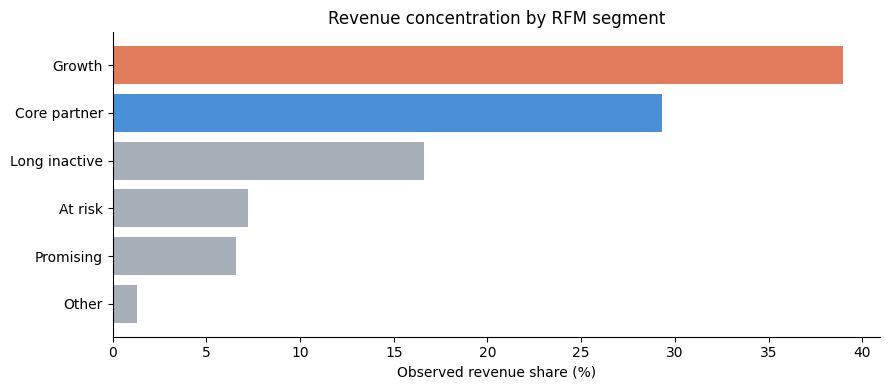

In [3]:
display(segment)
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E07B5B', '#4A90D9'] + ['#A7B0B8'] * (len(segment) - 2)
segment_labels = ['Growth', 'Core partner', 'Long inactive', 'At risk', 'Promising', 'Other']
ax.barh(segment_labels[::-1], segment['revenue_share_pct'][::-1], color=colors[::-1])
ax.set_xlabel('Observed revenue share (%)')
ax.set_title('Revenue concentration by RFM segment')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. 첫 구매월 코호트

m0는 기준월 100%, 빈칸은 아직 관측되지 않은 미래 월이다. m1 9.68%는 관측 가능한 11개 코호트의 단순평균이다.

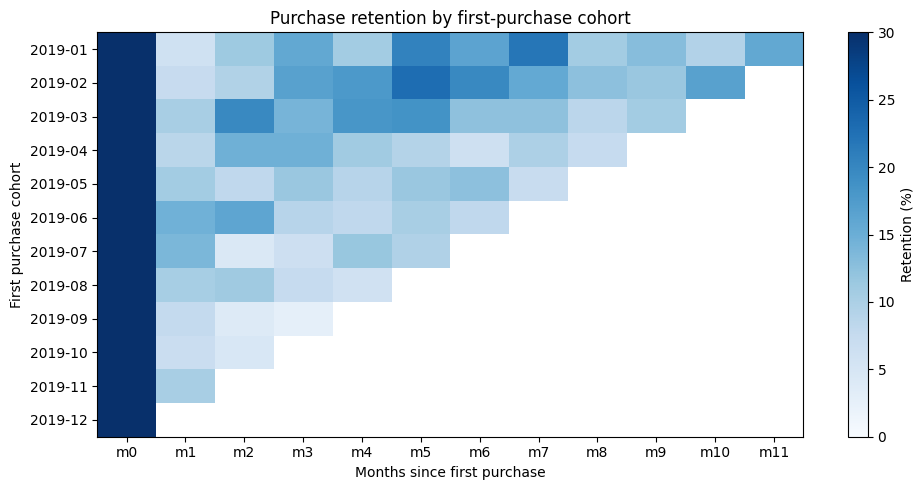

In [4]:
matrix = cohort[[f'm{i}' for i in range(12)]].to_numpy(dtype=float)
masked = np.ma.masked_invalid(matrix)
fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(masked, aspect='auto', cmap='Blues', vmin=0, vmax=30)
ax.set_xticks(range(12), [f'm{i}' for i in range(12)])
ax.set_yticks(range(12), cohort['first_purchase_month'])
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('First purchase cohort')
ax.set_title('Purchase retention by first-purchase cohort')
fig.colorbar(image, ax=ax, label='Retention (%)')
plt.tight_layout()
plt.show()

## 4. 전체 관측기간의 거래 활동 단계

이 표는 시간 순서 funnel이 아니라 거래 고객 안에서 정의한 중첩 집합이다.

,stage,stage_name,reached,previous_stage_conversion_pct,dropoff_pct,interpretation
0,1,거래 고객,1468,NaN,NaN,2019년 거래ID가 1개 이상인 분석 모집단
1,2,거래ID 2개 이상,1343,91.49,8.51,서로 다른 거래ID가 2개 이상인 고객
2,3,거래ID 5개 이상,1139,84.81,15.19,서로 다른 거래ID가 5개 이상인 고객
3,4,우선 관리 세그먼트,471,41.35,58.65,RFM 규칙상 핵심 파트너 또는 성장형 고객


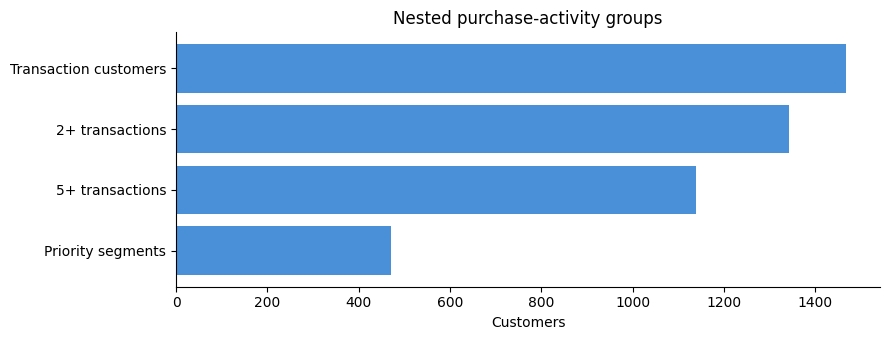

In [5]:
display(activity)
fig, ax = plt.subplots(figsize=(9, 3.5))
activity_labels = ['Transaction customers', '2+ transactions', '5+ transactions', 'Priority segments']
ax.barh(activity_labels[::-1], activity['reached'][::-1], color='#4A90D9')
ax.set_xlabel('Customers')
ax.set_title('Nested purchase-activity groups')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. 쿠폰 사용 고객의 관찰 차이와 균형

`Used`는 무작위 배정이 아닌 자기선택 행동이다. 72쌍 매칭 후에도 6/16 공변량이 기준 밖이므로 아래 수치는 ATT나 인과효과가 아니다.

,outcome,method,n_treat,n_control,estimate,ci_lower,ci_upper,unit
0,60일 재구매율,단순 차이,1208,72,25.55,20.14,30.24,percentage point
1,60일 재구매율,72쌍 매칭 차이,72,72,34.72,22.22,45.83,percentage point
2,60일 상품매출,단순 차이,1208,72,487.46,403.33,601.84,USD
3,60일 상품매출,72쌍 매칭 차이,72,72,964.75,346.75,2047.27,USD


,covariate,smd_before,smd_after,abs_smd_after
3,region_Chicago,0.137968,0.270269,0.270269
7,first_purchase_month_10,0.051060,-0.227485,0.227485
11,first_purchase_month_5,0.115966,-0.138376,0.138376
4,region_New Jersey,-0.081058,-0.135764,0.135764
12,first_purchase_month_6,0.139532,-0.120645,0.120645
9,first_purchase_month_3,0.039045,0.117438,0.117438
15,first_purchase_month_9,-0.039909,0.099930,0.099930
6,region_Washington DC,0.135069,-0.096680,0.096680
5,region_New York,0.001102,-0.067962,0.067962
2,gender_M,0.114763,0.058540,0.058540


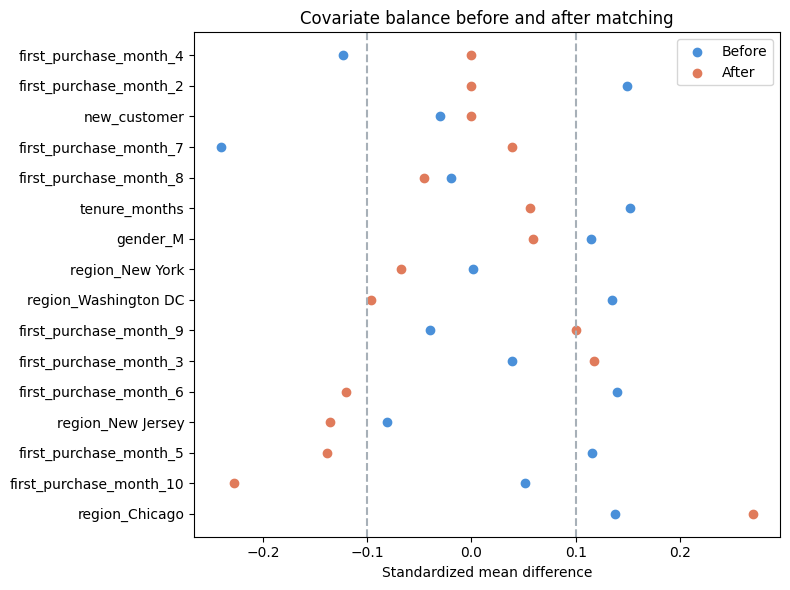

In [6]:
display(effects)
balance_view = balance.assign(abs_smd_after=balance['smd_after'].abs()).sort_values('abs_smd_after', ascending=False)
display(balance_view.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
positions = np.arange(len(balance_view))
ax.scatter(balance_view['smd_before'], positions, label='Before', color='#4A90D9')
ax.scatter(balance_view['smd_after'], positions, label='After', color='#E07B5B')
ax.axvline(-0.1, color='#A7B0B8', linestyle='--')
ax.axvline(0.1, color='#A7B0B8', linestyle='--')
ax.set_yticks(positions, balance_view['covariate'])
ax.set_xlabel('Standardized mean difference')
ax.set_title('Covariate balance before and after matching')
ax.legend()
plt.tight_layout()
plt.show()

## 결론과 다음 의사결정

- 성장형과 핵심 파트너 세그먼트가 관측 매출의 68.3%를 차지하지만, Monetary가 분류 변수라는 순환성을 함께 밝힌다.
- 첫 구매 다음 달의 낮은 구매 리텐션을 CRM 실험 우선 구간으로 본다.
- 쿠폰 매칭 결과는 양의 관찰 차이를 보이지만 잔여 불균형과 자기선택 때문에 효과로 확정하지 않는다.
- 다음 단계는 첫 구매 후 14일 미구매 고객을 대상으로 한 3-arm 무작위 실험이다.